In [2]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import fastf1 as ff1
import fastf1.plotting
#from fastf1 import Laps
from timple.timedelta import strftimedelta
#from fastf1.core import Laps

import collections
from functools import cached_property
import logging
# import warnings

import numpy as np
import pandas as pd

from fastf1 import api, ergast
from fastf1.utils import recursive_dict_get, to_timedelta
from fastf1.core import Laps

import warnings
import os

import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import datetime
import seaborn as sns
sns.set_style("darkgrid")
import pandas as pd
import numpy as np
#pd.set_option('display.max_columns', None)

In [2]:
fastf1.plotting.setup_mpl()  # Setup matplotlib for fastf1

/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:90: FutureWarning: FastF1 will no longer silently modify the default Matplotlib colors in the future.
To remove this warning, explicitly set `color_scheme=None` or `color_scheme='fastf1'` when calling `.setup_mpl()`.
  warnings.warn(
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:98: FutureWarning: FastF1 will stop modifying the default Matplotlib settings in the future.
To opt-in to the new behaviour and remove this warning, explicitly set `misc_mpl_mods=False` when calling `.setup_mpl()`.
  warnings.warn(


In [3]:
if not os.path.exists('cache'):
    os.makedirs('cache')
ff1.Cache.enable_cache('cache')  # Enable caching

In [22]:
DutchGP25 = ff1.get_session(2025, 15, 'R')  # Get the 2025 Dutch Grand
DutchGP25.load()  # Load the session data

DutchQ25 = ff1.get_session(2025, 15, 'Q')  # Get the 2025 Dutch Grand Prix Qualifying session
DutchQ25.load()  # Load the session data

core           INFO 	Loading data for Dutch Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '6', '63', '23', '87', '18', '14', '22', '31', '43', '30', '55', '27', '5', '12', '10', '4', '16', '44']
core           INFO 	Loading data for Dutch Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req

In [5]:
race_name = DutchGP25.event.OfficialEventName
race_name

'FORMULA 1 HEINEKEN DUTCH GRAND PRIX 2025'

In [6]:
print("✅ Race data loaded successfully!")
print(f"🏁 Race: {DutchGP25.event['EventName']}")
print(f"📅 Date: {DutchGP25.event['EventDate']}")
print(f"📍 Location: {DutchGP25.event['Location']}, {DutchGP25.event['Country']}")

✅ Race data loaded successfully!
🏁 Race: Dutch Grand Prix
📅 Date: 2025-08-31 00:00:00
📍 Location: Zandvoort, Netherlands


fix the result from decimal to fix one place fixed. 

In [28]:
# fix the decimal for the grid position and position gained.

# Get race results
results = DutchGP25.results

# Create a clean results DataFrame
results_df = pd.DataFrame({
    'Position': results['Position'].astype(int),
    'Driver': results['Abbreviation'],
    'Team': results['TeamName'],
    'Points': results['Points'].astype(int),
    'Status': results['Status'],
    'GridPosition': results['GridPosition'].astype(int)
})

results_df['Positions_Gained'] = (results_df['GridPosition'] - results_df['Position']).astype(int)

print("🏁 2025 DUTCH GRAND PRIX - FINAL RESULTS\n")
print(results_df.to_string(index=False))
print("\n" + "="*80)

🏁 2025 DUTCH GRAND PRIX - FINAL RESULTS

 Position Driver            Team  Points   Status  GridPosition  Positions_Gained
        1    PIA         McLaren      25 Finished             1                 0
        2    VER Red Bull Racing      18 Finished             3                 1
        3    HAD    Racing Bulls      15 Finished             4                 1
        4    RUS        Mercedes      12 Finished             5                 1
        5    ALB        Williams      10 Finished            15                10
        6    BEA    Haas F1 Team       8 Finished            20                14
        7    STR    Aston Martin       6 Finished            19                12
        8    ALO    Aston Martin       4 Finished            10                 2
        9    TSU Red Bull Racing       2 Finished            12                 3
       10    OCO    Haas F1 Team       1 Finished            18                 8
       11    COL          Alpine       0 Finished        

/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:154: FutureWarning: INCOMPATIBLE with 2025 season! The function `driver_color` is deprecated and will be removed in a future version. Use `fastf1.plotting.get_driver_color` instead.
  warnings.warn("INCOMPATIBLE with 2025 season! The function `driver_color` "


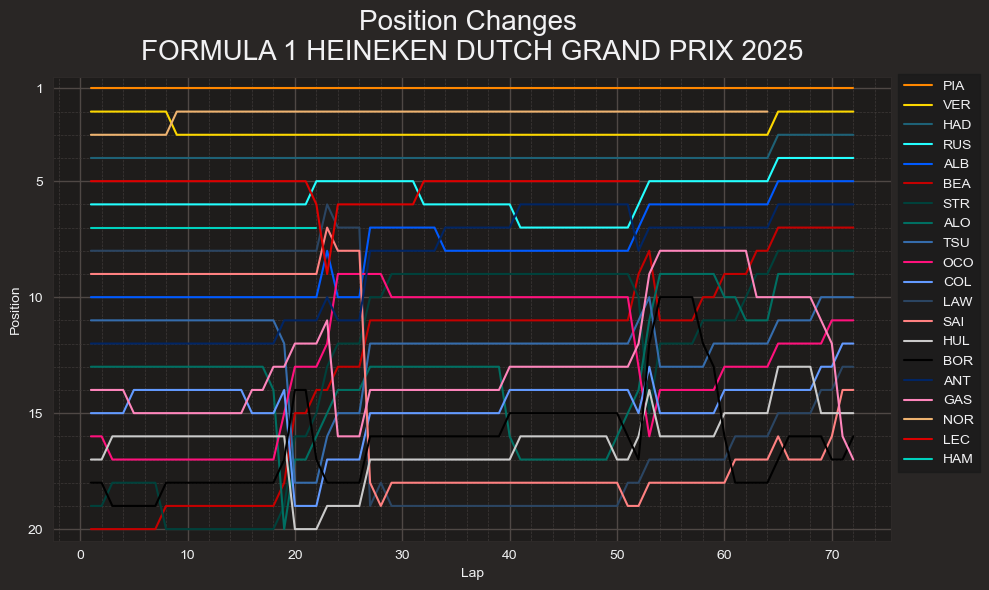

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for drv in DutchGP25.drivers:
    drv_laps = DutchGP25.laps.pick_driver(drv)

    abb = drv_laps['Driver'].iloc[0]
    try:
        color = fastf1.plotting.driver_color(abb)
    except KeyError:
        color = 'black'  # fallback colour for unknown drivers


    ax.plot(drv_laps['LapNumber'], drv_laps['Position'], label=abb, color=color)

ax.set_ylim([20.5, 0.5])
ax.set_yticks([1, 5, 10, 15, 20])
ax.set_xlabel('Lap')
ax.set_ylabel('Position')    
ax.legend(bbox_to_anchor=(1.0, 1.02))
ax.set_title('Position Changes \n'+race_name, fontsize=20)
plt.tight_layout()
plt.show()

In [25]:
DutchGP25.race_control_messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2025-08-31 12:17:58,Flag,YELLOW IN TRACK SECTOR 16,None,YELLOW,Sector,16.0,None,1
1,2025-08-31 12:17:59,Flag,YELLOW IN TRACK SECTOR 17,None,YELLOW,Sector,17.0,None,1
2,2025-08-31 12:18:28,Flag,CLEAR IN TRACK SECTOR 16,None,CLEAR,Sector,16.0,None,1
3,2025-08-31 12:18:28,Flag,CLEAR IN TRACK SECTOR 17,None,CLEAR,Sector,17.0,None,1
4,2025-08-31 12:20:00,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
...,...,...,...,...,...,...,...,...,...
103,2025-08-31 14:45:05,Other,ALL PASS HOLDERS MAY ACCESS THE PIT LANE,None,None,None,NaN,None,72
104,2025-08-31 14:45:34,Flag,DOUBLE YELLOW IN TRACK SECTOR 11,None,DOUBLE YELLOW,Sector,11.0,None,72
105,2025-08-31 14:49:09,Flag,CLEAR IN TRACK SECTOR 11,None,CLEAR,Sector,11.0,None,72
106,2025-08-31 14:49:10,Flag,DOUBLE YELLOW IN TRACK SECTOR 11,None,DOUBLE YELLOW,Sector,11.0,None,72


In [34]:
# fix the decimal since the decimal would never be use in the race.
# Fastest laps analysis
print("⚡ FASTEST LAPS ANALYSIS\n")

fastest_laps = []
for driver in DutchGP25.drivers:
    driver_laps = DutchGP25.laps.pick_driver(driver)
    fastest_lap = driver_laps.pick_fastest()
    if fastest_lap is not None and not pd.isna(fastest_lap['LapTime']):
        fastest_laps.append({
            'Driver': driver,
            'Team': fastest_lap['Team'],
            'LapTime': fastest_lap['LapTime'],
            'LapNumber': int(fastest_lap['LapNumber']),  # ← fixed here
            'Compound': fastest_lap['Compound']
        })
def format_laptime(td):
    total_seconds = td.total_seconds()
    minutes = int(total_seconds // 60)
    seconds = total_seconds % 60
    return f"{minutes}:{seconds:06.3f}"

fastest_df = pd.DataFrame(fastest_laps).sort_values('LapTime')
fastest_df['Gap'] = fastest_df['LapTime'] - fastest_df['LapTime'].min()

fastest_df['LapTime'] = fastest_df['LapTime'].apply(format_laptime)
fastest_df['Gap'] = fastest_df['Gap'].apply(lambda x: f"+{x.total_seconds():.3f}s")

print(fastest_df[['Driver', 'Team', 'LapTime', 'Gap', 'LapNumber', 'Compound']].to_string(index=False))
print(f"\n🏁 Fastest lap: {fastest_df.iloc[0]['Driver']} - {fastest_df.iloc[0]['LapTime']}")

⚡ FASTEST LAPS ANALYSIS

Driver            Team  LapTime     Gap  LapNumber Compound
    81         McLaren 1:12.271 +0.000s         60     HARD
     4         McLaren 1:12.379 +0.108s         59     HARD
     1 Red Bull Racing 1:12.921 +0.650s         70     SOFT
    43          Alpine 1:13.049 +0.778s         72     SOFT
     6    Racing Bulls 1:13.327 +1.056s         70     SOFT
    12        Mercedes 1:13.480 +1.209s         70     SOFT
    23        Williams 1:13.687 +1.416s         70     SOFT
    14    Aston Martin 1:13.719 +1.448s         42     HARD
    63        Mercedes 1:13.728 +1.457s         70     SOFT
    55        Williams 1:13.808 +1.537s         58     SOFT
    18    Aston Martin 1:13.822 +1.551s         70     HARD
    30    Racing Bulls 1:13.879 +1.608s         60     SOFT
    87    Haas F1 Team 1:13.950 +1.679s         70   MEDIUM
    31    Haas F1 Team 1:13.986 +1.715s         71   MEDIUM
     5     Kick Sauber 1:14.307 +2.036s         63     SOFT
    22 Red Bull

/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_driver

req            INFO 	Using cached data for driver_info
/var/folders/34/52dhlcl91bgb4dvzhxk9kbv40000gn/T/ipykernel_80867/1905935934.py:25: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:373: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  return _savefig_placeholder(*args, **kwargs)
/var/folders/34/52dhlcl91bgb4dvzhxk9kbv40000gn/T/ipykernel_80867/1905935934.py:26: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.savefig('Dutchgp_2025_fastest_laps.png', dpi=300, bbox_inches='tight', facecolor='#0e1117')
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


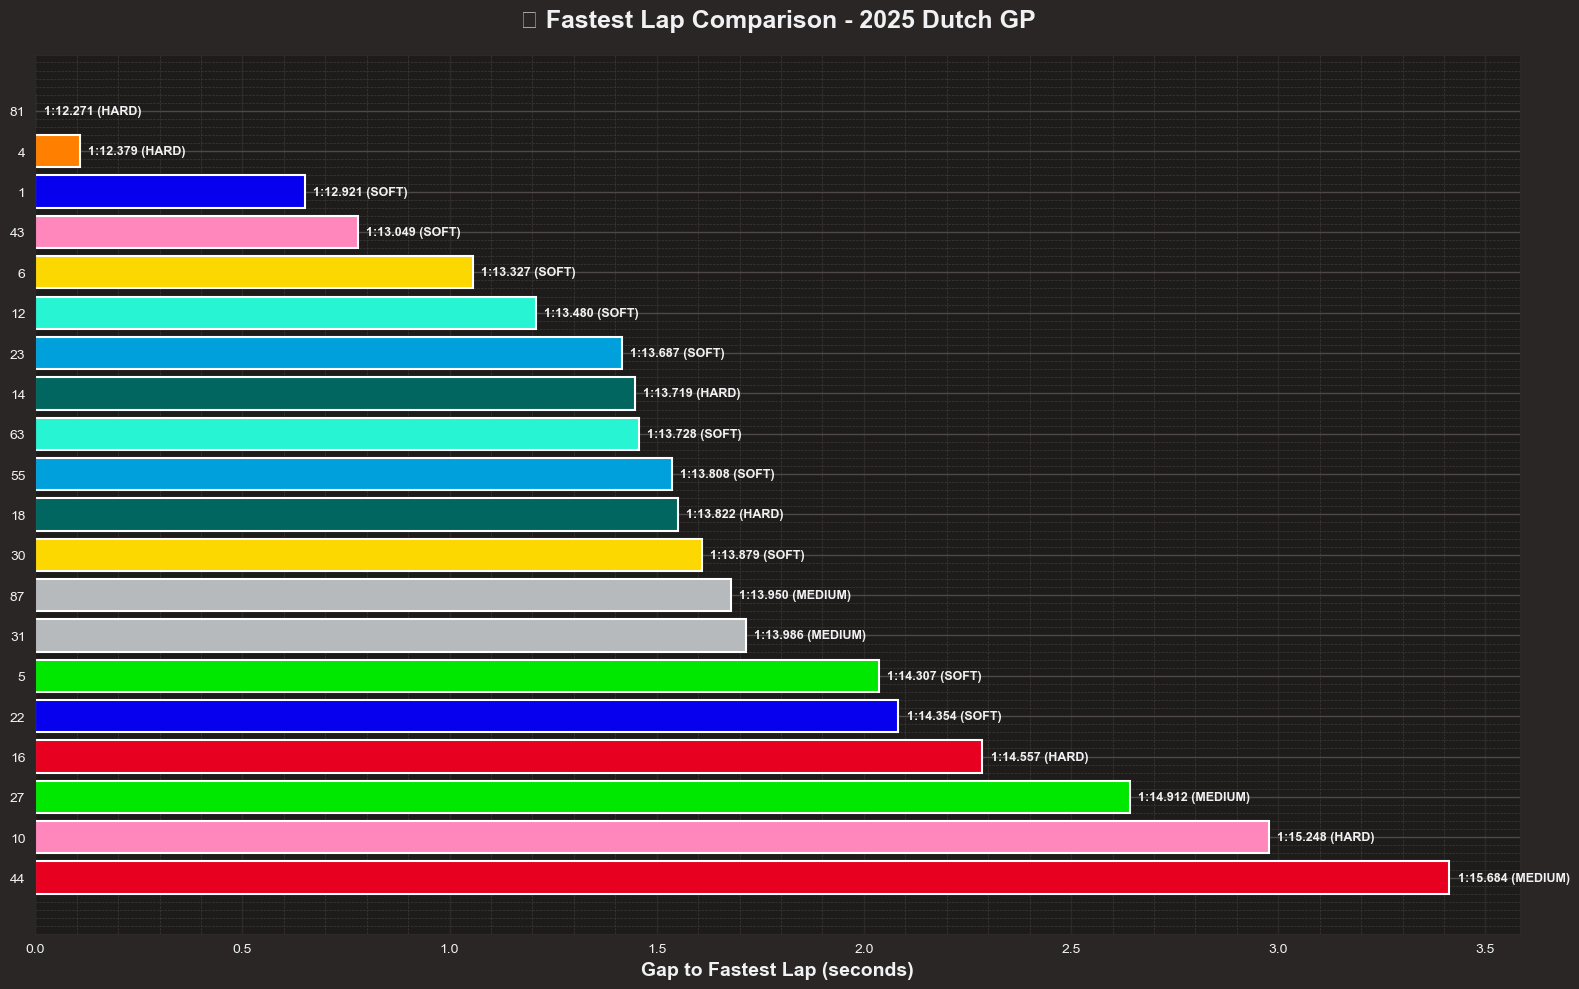

In [10]:
# Visualize fastest laps
fig, ax = plt.subplots(figsize=(16, 10))

# Get driver abbreviations for consistent color lookup
driver_abbreviations = [DutchGP25.get_driver(driver_id).Abbreviation for driver_id in fastest_df['Driver']]
colors = [fastf1.plotting.get_driver_color(abbr, session=DutchGP25) for abbr in driver_abbreviations]
bars = ax.barh(fastest_df['Driver'], fastest_df['Gap'], color=colors,
               edgecolor='white', linewidth=1.5)

ax.set_xlabel('Gap to Fastest Lap (seconds)', fontsize=14, fontweight='bold')
ax.set_title('⚡ Fastest Lap Comparison - 2025 Dutch GP',
             fontsize=18, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add lap time labels
for i, (bar, laptime, compound) in enumerate(zip(bars, fastest_df['LapTime'], fastest_df['Compound'])):
    width = bar.get_width()
    minutes = int(laptime // 60)
    seconds = laptime % 60
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2.,
             f'{minutes}:{seconds:06.3f} ({compound})',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Dutchgp_2025_fastest_laps.png', dpi=300, bbox_inches='tight', facecolor='#0e1117')
plt.show()

/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"



📈 Analyzing lap time evolution for top 5 finishers...



/var/folders/34/52dhlcl91bgb4dvzhxk9kbv40000gn/T/ipykernel_80867/1203814959.py:30: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/52dhlcl91bgb4dvzhxk9kbv40000gn/T/ipykernel_80867/1203814959.py:30: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:373: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  return _savefig_placeholder(*args, **kwargs)
/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:373: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  return _savefig_placeholder(*args, **kwargs)
/var/folders/34/52dhlcl91bgb4dvzhxk9kbv40000gn/T/ipykernel_80867/1203814959.py:31: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.savefig('Dutch_2025_lap_e

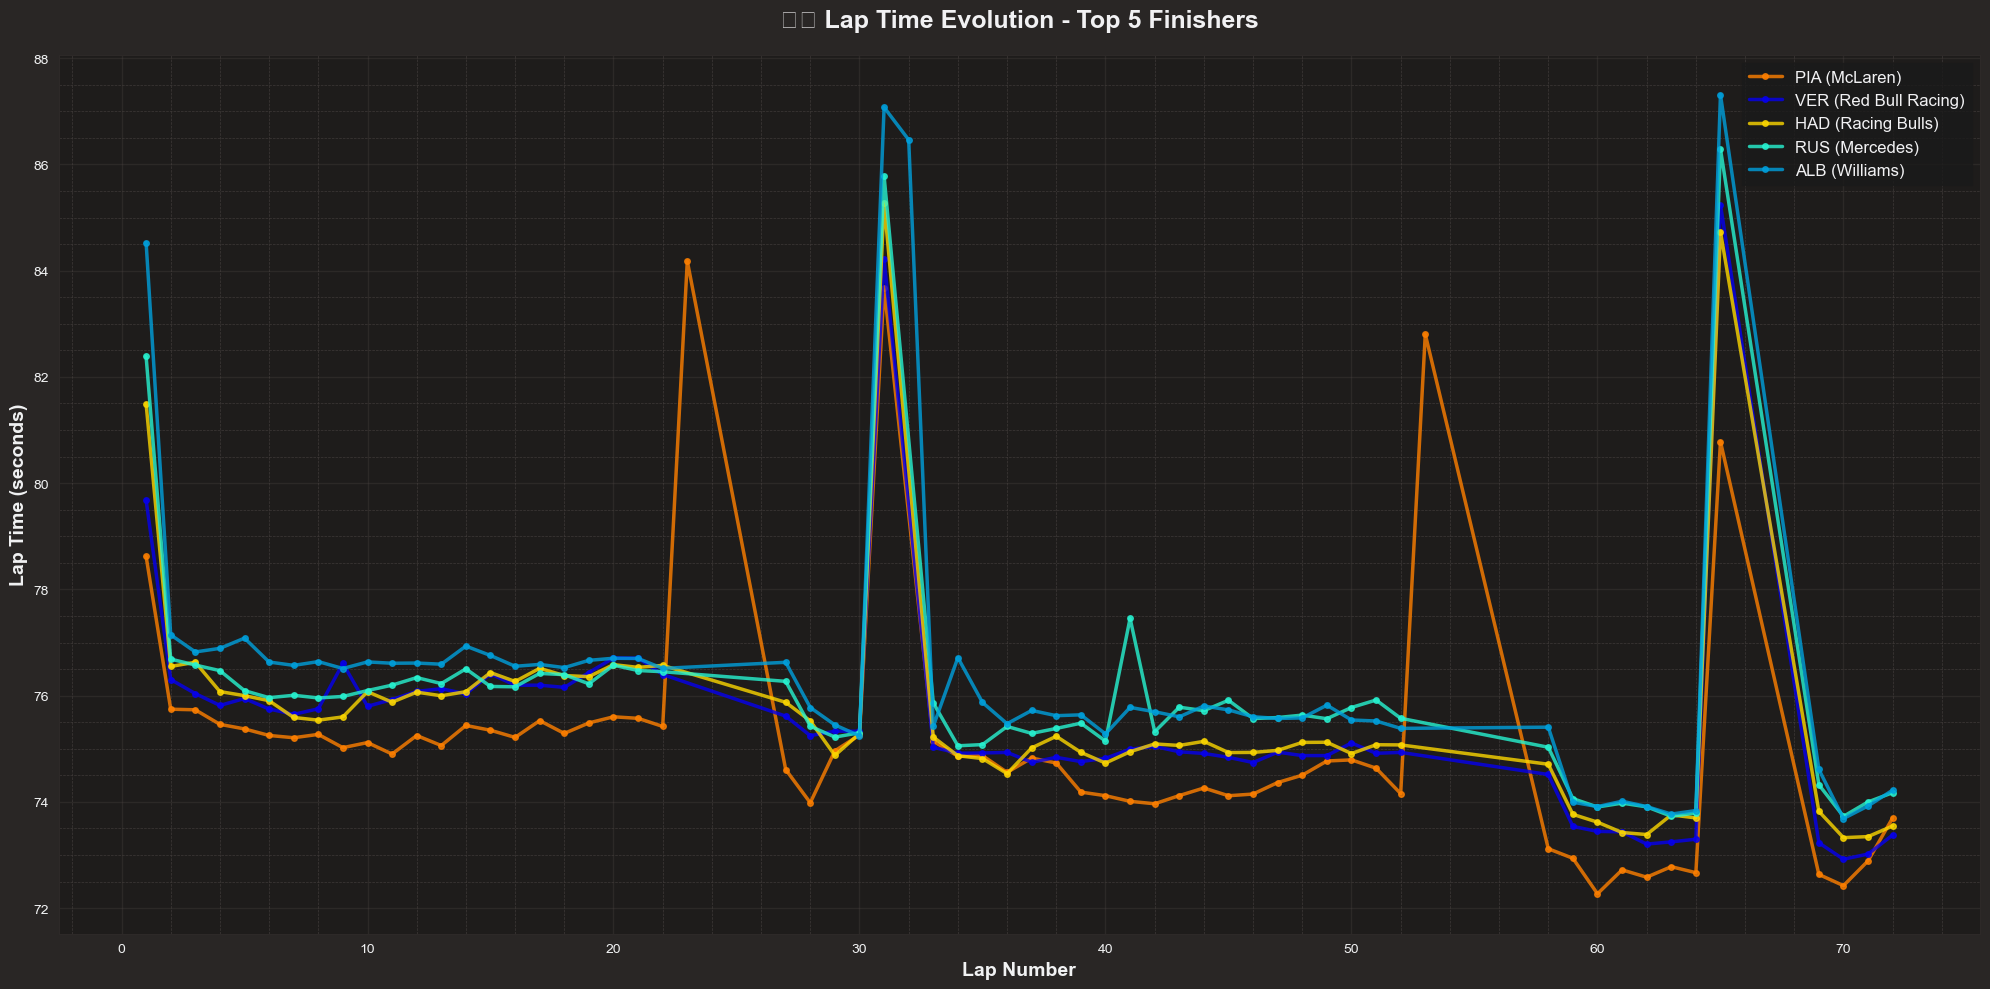

In [11]:
# Lap time evolution for top 5 finishers
print("\n📈 Analyzing lap time evolution for top 5 finishers...\n")

fig, ax = plt.subplots(figsize=(20, 10))

top5_drivers = results_df.head(5)['Driver'].tolist()

for driver in top5_drivers:
    driver_laps = DutchGP25.laps.pick_driver(driver)
    # Filter out slow laps (pit stops, incidents, etc.)
    median_time = driver_laps['LapTime'].dt.total_seconds().median()
    driver_laps = driver_laps[driver_laps['LapTime'].dt.total_seconds() < median_time * 1.15]

    color = fastf1.plotting.get_driver_color(driver, session=DutchGP25)

    lap_times = driver_laps['LapTime'].dt.total_seconds()
    lap_numbers = driver_laps['LapNumber']

    team = driver_laps.iloc[0]['Team']
    ax.plot(lap_numbers, lap_times, color=color, linewidth=2.5,
            label=f"{driver} ({team})", marker='o', markersize=4, alpha=0.8)

ax.set_xlabel('Lap Number', fontsize=14, fontweight='bold')
ax.set_ylabel('Lap Time (seconds)', fontsize=14, fontweight='bold')
ax.set_title('⏱️ Lap Time Evolution - Top 5 Finishers',
             fontsize=18, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.savefig('Dutch_2025_lap_evolution.png', dpi=300, bbox_inches='tight', facecolor='#0e1117')
plt.show()

In [12]:
DutchQ25 = ff1.get_session(2025, 15, 'Q')  # Load the Abu Dhabi Grand Prix session
DutchQ25.load()  # Download the data and process it

core           INFO 	Loading data for Dutch Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '6', '63', '16', '44', '30', '55', '14', '12', '22', '5', '10', '23', '43', '27', '31', '87', '18']


In [13]:
DutchQ25.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,CountryCode,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,,1.0,,NaN,0 days 00:01:09.338000,0 days 00:01:08.964000,0 days 00:01:08.662000,NaT,,NaN
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,,2.0,,NaN,0 days 00:01:09.469000,0 days 00:01:08.874000,0 days 00:01:08.674000,NaT,,NaN
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,,3.0,,NaN,0 days 00:01:09.696000,0 days 00:01:09.122000,0 days 00:01:08.925000,NaT,,NaN
6,6,I HADJAR,HAD,hadjar,Racing Bulls,6C98FF,rb,Isack,Hadjar,Isack Hadjar,...,,4.0,,NaN,0 days 00:01:09.966000,0 days 00:01:09.439000,0 days 00:01:09.208000,NaT,,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,,5.0,,NaN,0 days 00:01:09.676000,0 days 00:01:09.313000,0 days 00:01:09.255000,NaT,,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,,6.0,,NaN,0 days 00:01:09.906000,0 days 00:01:09.304000,0 days 00:01:09.340000,NaT,,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,,7.0,,NaN,0 days 00:01:09.900000,0 days 00:01:09.261000,0 days 00:01:09.390000,NaT,,NaN
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,,8.0,,NaN,0 days 00:01:09.779000,0 days 00:01:09.383000,0 days 00:01:09.500000,NaT,,NaN
55,55,C SAINZ,SAI,sainz,Williams,1868DB,williams,Carlos,Sainz,Carlos Sainz,...,,9.0,,NaN,0 days 00:01:09.980000,0 days 00:01:09.472000,0 days 00:01:09.505000,NaT,,NaN
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,,10.0,,NaN,0 days 00:01:09.950000,0 days 00:01:09.366000,0 days 00:01:09.630000,NaT,,NaN


In [26]:
print(driver)

['VER' 'GAS' 'ANT' 'ALO' 'LEC' 'STR' 'TSU' 'ALB' 'HUL' 'LAW' 'OCO' 'NOR'
 'COL' 'HAM' 'BOR' 'SAI' 'HAD' 'RUS' 'PIA' 'BEA']


In [14]:
driver = pd.unique(DutchGP25.laps['Driver'])
driver

array(['VER', 'GAS', 'ANT', 'ALO', 'LEC', 'STR', 'TSU', 'ALB', 'HUL',
       'LAW', 'OCO', 'NOR', 'COL', 'HAM', 'BOR', 'SAI', 'HAD', 'RUS',
       'PIA', 'BEA'], dtype=object)

In [15]:
race_name = DutchGP25.event.OfficialEventName
race_name

'FORMULA 1 HEINEKEN DUTCH GRAND PRIX 2025'

/Users/yashberawala/anaconda3/envs/PythonData/lib/python3.11/site-packages/fastf1/plotting/__init__.py:84: FutureWarning: INCOMPATIBLE with 2025 season! COMPOUND_COLORS is deprecated and will be removed in a future version.
  warnings.warn(f"INCOMPATIBLE with 2025 season! {name} is deprecated "


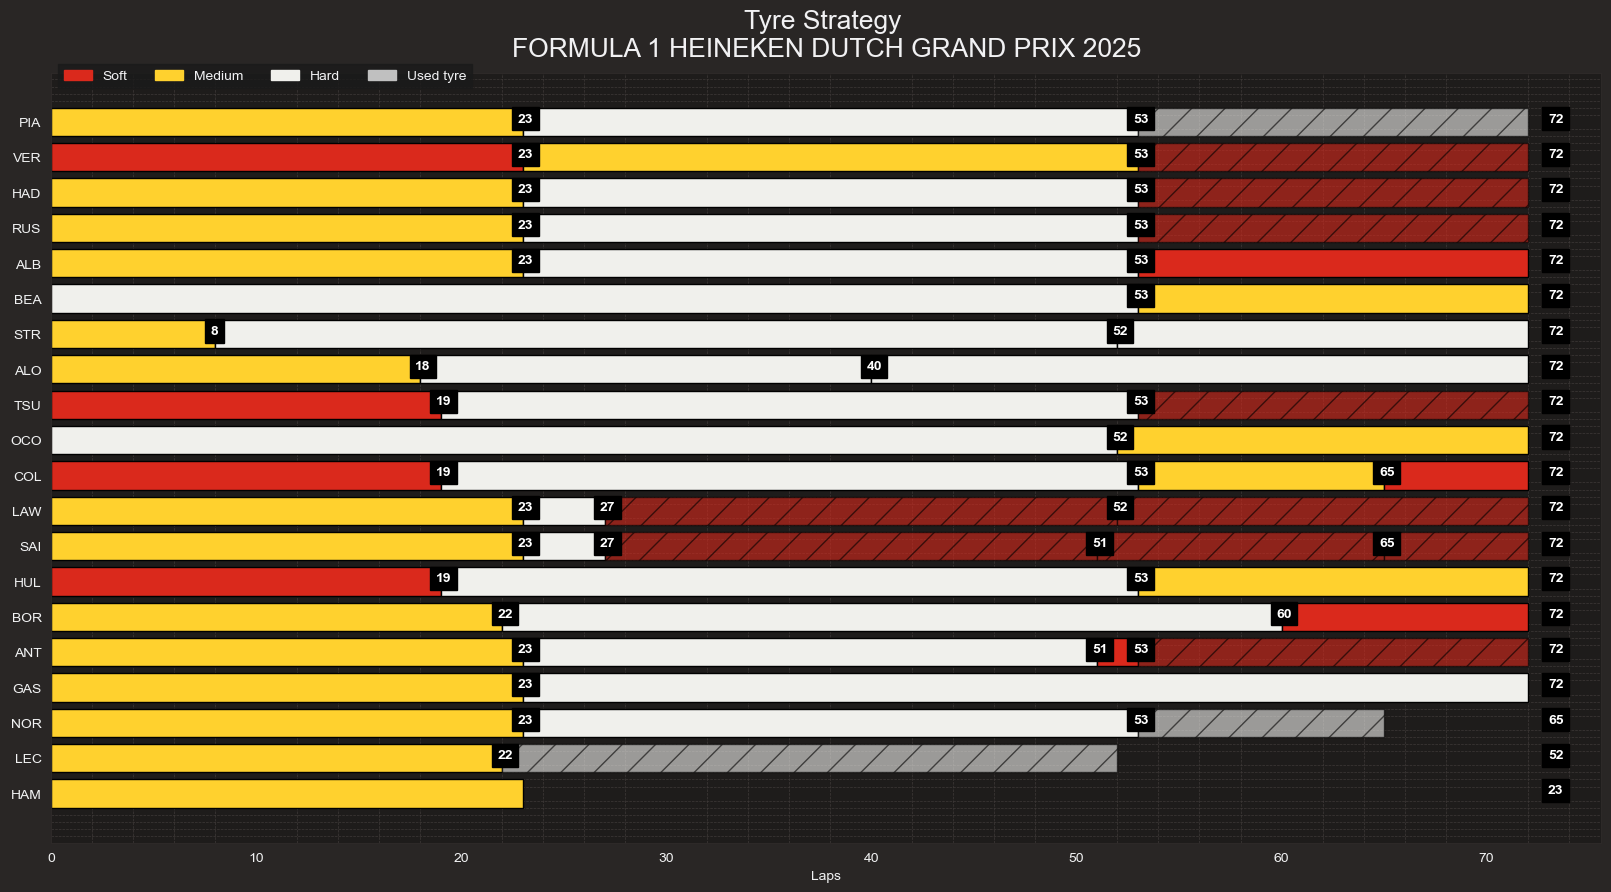

In [16]:
import matplotlib as mpatches
fig, ax = plt.subplots(figsize=(20, 10))
plt.title('Tyre Strategy \n'+race_name)
plt.xlabel('Laps')
plt.grid(False)

# Tyre Stint
compound_color = {key: value for key,value in fastf1.plotting.COMPOUND_COLORS.items()}
df = DutchGP25.laps.copy()
tyre_stint = df.groupby(['Driver','Stint','Compound','FreshTyre']).agg({'LapNumber': 'min', 'TyreLife': 'count'}).reset_index()

for drv in list(DutchGP25.results.Abbreviation)[::-1]:
    driver_stints = tyre_stint[tyre_stint['Driver']== drv]

    for idx, row in driver_stints.iterrows():
        plt.barh(
            y=drv,
            width=row["TyreLife"],
            left=max(row['LapNumber']-1, 0),
            color=compound_color[row.Compound],
            edgecolor="black",
            fill=True,
            # for new/old tyre
            alpha = 0.6 if not row.FreshTyre else 1, hatch = '/' if not row.FreshTyre else None
        )

        if not row['LapNumber'] <= 1.0:
            plt.text(row['LapNumber']-1.25, drv, round(row['LapNumber']-1), fontweight='extra bold', backgroundcolor='black', color = 'white')

    plt.text(df.LapNumber.max()+1, drv, driver_stints['TyreLife'].sum(), fontweight='extra bold', backgroundcolor='black', color = 'white')
# Define colors for the compounds 
soft_patch = mpatches.patches.Patch(color=compound_color['SOFT'], label = 'Soft')
medium_patch = mpatches.patches.Patch(color=compound_color['MEDIUM'], label = 'Medium')
hard_patch = mpatches.patches.Patch(color=compound_color['HARD'], label = 'Hard')
intermediate_patch = mpatches.patches.Patch(color=compound_color['INTERMEDIATE'], label = 'Intermediate')
wet_patch = mpatches.patches.Patch(color=compound_color['WET'], label = 'Wet')

# Define the used tyre patch
used_patch = mpatches.patches.Patch(color ='silver', hatch = 'x', label = 'Used tyre')

# add the legend to the plot
plt.legend(handles = [soft_patch, medium_patch, hard_patch, used_patch], loc = 'upper left', bbox_to_anchor=(0, 1.02), ncol=4)

# # Add the legend to the plot, move it outside the graph, and display the labels in a single line
# plt.legend(handles=[soft_patch, medium_patch, hard_patch, used_patch], loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

# plt.show()

plt.autoscale()  
# Define compound colors 
#compound_color = {key: value for key, value in fastf1.plotting.COMPOUND_COLORS.items()}



In [17]:
# Load Qualifying Data
print(f"📊 Session loaded: {DutchQ25.event['EventName']} - {DutchQ25.name}")
print(f"📍 Circuit: {DutchQ25.event['Location']}")
print(f"📅 Date: {DutchQ25.event['EventDate']}")

📊 Session loaded: Dutch Grand Prix - Qualifying
📍 Circuit: Zandvoort
📅 Date: 2025-08-31 00:00:00


In [29]:
# ## 🏆 Q3 Results and Top 10 Analysis

# Get Q3 results
q3_results = DutchQ25.results.head(10)

# Display formatted results
print("\n" + "="*60)
print("🏁 Q3 QUALIFYING RESULTS - TOP 10")
print("="*60)
results_df = q3_results[['Position', 'Abbreviation', 'TeamName', 'Q3']].copy()
results_df['Position'] = results_df['Position'].astype(int)
results_df['Gap'] = q3_results['Q3'] - q3_results['Q3'].min()
results_df['Gap'] = results_df['Gap'].apply(lambda x: f"+{x.total_seconds():.3f}s" if x.total_seconds() > 0 else "POLE")
print(results_df.to_string(index=False))
print("="*60)


🏁 Q3 QUALIFYING RESULTS - TOP 10
 Position Abbreviation        TeamName                     Q3     Gap
        1          PIA         McLaren 0 days 00:01:08.662000    POLE
        2          NOR         McLaren 0 days 00:01:08.674000 +0.012s
        3          VER Red Bull Racing 0 days 00:01:08.925000 +0.263s
        4          HAD    Racing Bulls 0 days 00:01:09.208000 +0.546s
        5          RUS        Mercedes 0 days 00:01:09.255000 +0.593s
        6          LEC         Ferrari 0 days 00:01:09.340000 +0.678s
        7          HAM         Ferrari 0 days 00:01:09.390000 +0.728s
        8          LAW    Racing Bulls 0 days 00:01:09.500000 +0.838s
        9          SAI        Williams 0 days 00:01:09.505000 +0.843s
       10          ALO    Aston Martin 0 days 00:01:09.630000 +0.968s


In [31]:
# ## 🏆 Q2 Results and Top 10 Analysis

# Get Q2 results
q2_results = DutchQ25.results.head(15)

# Display formatted results
print("\n" + "="*60)
print("🏁 Q2 QUALIFYING RESULTS - TOP 10")
print("="*60)
results_df = q2_results[['Position', 'Abbreviation', 'TeamName', 'Q2']].copy()
results_df['Position'] = results_df['Position'].astype(int)
results_df['Gap'] = q2_results['Q2'] - q2_results['Q2'].min()
results_df['Gap'] = results_df['Gap'].apply(lambda x: f"+{x.total_seconds():.3f}s" if x.total_seconds() > 0 else "POLE")
print(results_df.to_string(index=False))
print("="*60)


🏁 Q2 QUALIFYING RESULTS - TOP 10
 Position Abbreviation        TeamName                     Q2     Gap
        1          PIA         McLaren 0 days 00:01:08.964000 +0.090s
        2          NOR         McLaren 0 days 00:01:08.874000    POLE
        3          VER Red Bull Racing 0 days 00:01:09.122000 +0.248s
        4          HAD    Racing Bulls 0 days 00:01:09.439000 +0.565s
        5          RUS        Mercedes 0 days 00:01:09.313000 +0.439s
        6          LEC         Ferrari 0 days 00:01:09.304000 +0.430s
        7          HAM         Ferrari 0 days 00:01:09.261000 +0.387s
        8          LAW    Racing Bulls 0 days 00:01:09.383000 +0.509s
        9          SAI        Williams 0 days 00:01:09.472000 +0.598s
       10          ALO    Aston Martin 0 days 00:01:09.366000 +0.492s
       11          ANT        Mercedes 0 days 00:01:09.493000 +0.619s
       12          TSU Red Bull Racing 0 days 00:01:09.622000 +0.748s
       13          BOR     Kick Sauber 0 days 00:01:09.6

In [30]:
# ## 🏆 Q1 Results – Full Field

# Sort all drivers by Q1 lap times
q1_results = DutchQ25.results.sort_values(by="Q1")

print("\n" + "="*60)
print("🏁 FULL Q1 QUALIFYING RESULTS – ALL DRIVERS")
print("="*60)

results_df = q1_results[['Position', 'Abbreviation', 'TeamName', 'Q1']].copy()
results_df['Position'] = results_df['Position'].astype(int)

# Calculate gap from fastest Q1 time
results_df['Gap'] = q1_results['Q1'] - q1_results['Q1'].min()
results_df['Gap'] = results_df['Gap'].apply(
    lambda x: f"+{x.total_seconds():.3f}s" if x.total_seconds() > 0 else "FASTEST"
)

print(results_df.to_string(index=False))
print("="*60)



🏁 FULL Q1 QUALIFYING RESULTS – ALL DRIVERS
 Position Abbreviation        TeamName                     Q1     Gap
        1          PIA         McLaren 0 days 00:01:09.338000 FASTEST
        2          NOR         McLaren 0 days 00:01:09.469000 +0.131s
        5          RUS        Mercedes 0 days 00:01:09.676000 +0.338s
        3          VER Red Bull Racing 0 days 00:01:09.696000 +0.358s
        8          LAW    Racing Bulls 0 days 00:01:09.779000 +0.441s
       15          ALB        Williams 0 days 00:01:09.792000 +0.454s
       11          ANT        Mercedes 0 days 00:01:09.845000 +0.507s
       14          GAS          Alpine 0 days 00:01:09.894000 +0.556s
        7          HAM         Ferrari 0 days 00:01:09.900000 +0.562s
        6          LEC         Ferrari 0 days 00:01:09.906000 +0.568s
       10          ALO    Aston Martin 0 days 00:01:09.950000 +0.612s
       12          TSU Red Bull Racing 0 days 00:01:09.954000 +0.616s
        4          HAD    Racing Bulls 0 days 

In [21]:
# --- Build Q1 table ---
q1_df = DutchQ25.results[['Abbreviation', 'Q1']].copy()
q1_df['Q1_gap'] = q1_df['Q1'] - q1_df['Q1'].min()
q1_df = q1_df.set_index('Abbreviation')

# --- Build Q2 table ---
q2_df = DutchQ25.results[['Abbreviation', 'Q2']].copy()
q2_df['Q2_gap'] = q2_df['Q2'] - q2_df['Q2'].min()
q2_df = q2_df.set_index('Abbreviation')

# --- Build Q3 table ---
q3_df = DutchQ25.results[['Abbreviation', 'Q3']].copy()
q3_df['Q3_gap'] = q3_df['Q3'] - q3_df['Q3'].min()
q3_df = q3_df.set_index('Abbreviation')

# --- Combine all into one DataFrame ---
qualifying_combined = (
    q1_df
    .join(q2_df, how='left')
    .join(q3_df, how='right')
)

def format_gap(x):
    return f"+{x.total_seconds():.3f}s" if pd.notnull(x) and x.total_seconds() > 0 else "POLE"

for col in ['Q1_gap', 'Q2_gap', 'Q3_gap']:
    qualifying_combined[col] = qualifying_combined[col].apply(format_gap)

print("\n" + "="*90)
print("🏁 QUALIFYING PROGRESSION: Q1 → Q2 → Q3")
print("="*90)
print(qualifying_combined)
print("="*90)



🏁 QUALIFYING PROGRESSION: Q1 → Q2 → Q3
                                 Q1   Q1_gap                     Q2   Q2_gap  \
Abbreviation                                                                   
PIA          0 days 00:01:09.338000     POLE 0 days 00:01:08.964000  +0.090s   
NOR          0 days 00:01:09.469000  +0.131s 0 days 00:01:08.874000     POLE   
VER          0 days 00:01:09.696000  +0.358s 0 days 00:01:09.122000  +0.248s   
HAD          0 days 00:01:09.966000  +0.628s 0 days 00:01:09.439000  +0.565s   
RUS          0 days 00:01:09.676000  +0.338s 0 days 00:01:09.313000  +0.439s   
LEC          0 days 00:01:09.906000  +0.568s 0 days 00:01:09.304000  +0.430s   
HAM          0 days 00:01:09.900000  +0.562s 0 days 00:01:09.261000  +0.387s   
LAW          0 days 00:01:09.779000  +0.441s 0 days 00:01:09.383000  +0.509s   
SAI          0 days 00:01:09.980000  +0.642s 0 days 00:01:09.472000  +0.598s   
ALO          0 days 00:01:09.950000  +0.612s 0 days 00:01:09.366000  +0.492s   


In [45]:
ff1.get_event_schedule(2025)

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


ValueError: Failed to load any schedule data.

In [44]:
print(fastf1.__version__)

3.5.3


In [47]:
DutchGP25 = ff1.get_session(2025, 15, 'R')  # Get the 2025 Dutch Grand
DutchGP25.load()  # Load the session data

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


ValueError: Failed to load any schedule data.